Link to GitHub repository: https://github.com/Stampe04/CSS_Assignment2.git

All group members contributed equally to this project

# Part 1: Mixing Patterns and Assortativity

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**

Import the necessary packages:

In [89]:
import json
import networkx as nx
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import numpy as np
import math

First we import the ```network_graph```.json file and load the data. Then we add the data (nodes, edges) to a graph using NetworkX.

In [90]:
with open("network_graph.json", "r", encoding="utf-8") as f:
    data = json.load(f)

G = nx.Graph()

# add nodes
for node in data["nodes"]:
    G.add_node(
        node["id"],
        name=node["display_name"],
        country=node["country_code"],
        citations=node["cited_by_count"],
        first_year=node["first_publication_year"]
    )

# add edges
for link in data["links"]:
    G.add_edge(
        link["source"],
        link["target"],
        weight=link["weight"]
    )

Before moving on, we compared the full network with the largest connected component. The results showed that there was not a huge difference between the full network and the largest connected component. For this reason, we decided that it would be best to continue with the full network:

In [91]:
largest_cc = max(nx.connected_components(G), key=len)
G_gcc = G.subgraph(largest_cc).copy()

print(G.number_of_nodes(), G.number_of_edges())
print(G_gcc.number_of_nodes(), G_gcc.number_of_edges())

15023 51565
14323 50284


We were asked to calculate the *assortativity coefficient* using the formula either provided in the lecture or from the paper provided by the professor. We used the ```collections``` module and the ```defaultdict``` function to generate a dictionary to hold the values $a_i$ and $b_i$.

In [92]:
def attribute_assortativity_manual(G, attr):
    """
    Manual assortativity for a categorical node attribute on an undirected graph.
    Based on mixing matrix logic:
        r = (sum_i e_ii - sum_i a_i b_i) / (1 - sum_i a_i b_i)
    """
    mix = defaultdict(int)

    # Count attribute pair frequencies across edges
    for u, v in G.edges():
        au = G.nodes[u].get(attr)
        av = G.nodes[v].get(attr)

        if au is None or av is None:
            continue

        # For undirected graphs, count both directions
        mix[(au, av)] += 1
        mix[(av, au)] += 1

    M = sum(mix.values())
    e = {k: val / M for k, val in mix.items()}

    a = defaultdict(float)
    b = defaultdict(float)

    for (i, j), val in e.items():
        a[i] += val
        b[j] += val

    sum_eii = sum(val for (i, j), val in e.items() if i == j)
    labels = set(a) | set(b)
    sum_aibi = sum(a[k] * b[k] for k in labels)

    r = (sum_eii - sum_aibi) / (1 - sum_aibi)
    return r

The manually calculated country assortativity then becomes: (Note: This is the answer that should be seen as the answer to the exercise)

In [ ]:
r_country = attribute_assortativity_manual(G, "country")
print(f"Manual country assortativity: {r_country:.3f}")

Manual country assortativity: 0.3956692679195351


As an additional sanity check, we compared our manually computed result to the value returned by ```NetworkX```. The difference between the manually computed assortativity and the value computed by ```NetworkX``` is quite small, which increases our confidence that the manual assortativity calculation is correct.

In [94]:
r_country = nx.attribute_assortativity_coefficient(G, "country")
print(f"nx Country assortativity: {r_country:.3f}")

nx Country assortativity: 0.395


> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.

We implemented the function below:

In [95]:
def canonical_edge(u, v):
    return (u, v) if u <= v else (v, u)

def double_edge_swap_configuration_model_fast(G, nswap=None, max_tries=None, seed=None):
    rng = random.Random(seed)
    H = G.copy()

    E = H.number_of_edges()
    if nswap is None:
        nswap = 10 * E
    if max_tries is None:
        max_tries = 20 * nswap

    # store edges in canonical form
    edge_list = [canonical_edge(u, v) for u, v in H.edges()]
    edge_pos = {e: i for i, e in enumerate(edge_list)}

    swaps = 0
    tries = 0

    while swaps < nswap and tries < max_tries:
        tries += 1

        i1, i2 = rng.sample(range(len(edge_list)), 2)
        e1 = edge_list[i1]
        e2 = edge_list[i2]

        u, v = e1
        x, y = e2

        # 50% flip of first edge
        if rng.random() < 0.5:
            u, v = v, u

        if u == y or v == x:
            continue

        new1 = canonical_edge(u, y)
        new2 = canonical_edge(x, v)

        # avoid self-loops
        if new1[0] == new1[1] or new2[0] == new2[1]:
            continue

        # avoid duplicate edges
        if new1 in edge_pos or new2 in edge_pos:
            continue

        # perform swap in graph
        H.remove_edge(*e1)
        H.remove_edge(*e2)
        H.add_edge(*new1)
        H.add_edge(*new2)

        # update edge_list + edge_pos in O(1)
        del edge_pos[e1]
        del edge_pos[e2]

        edge_list[i1] = new1
        edge_list[i2] = new2

        edge_pos[new1] = i1
        edge_pos[new2] = i2

        swaps += 1

    print(f"Successful swaps: {swaps}/{nswap}")
    print(f"Attempts: {tries}")
    return H

> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.

Before testing our algorithm with $10 \times E$ swaps, we ran a quick sanity check with just $2000$ swaps to ensure that it worked as expected. The results indicated that our implementation seemed to work:

In [96]:
G_rand = double_edge_swap_configuration_model_fast(G, nswap=2000, seed=42)
print(dict(G.degree()) == dict(G_rand.degree()))

Successful swaps: 2000/2000
Attempts: 2009
True


We then performed the full $10 \times E$ swaps. Our results showed that our implementation worked as expected:

In [97]:
def degree_dict(G):
    return dict(G.degree())

G_rand = double_edge_swap_configuration_model_fast(G, seed=42)

orig_deg = degree_dict(G)
rand_deg = degree_dict(G_rand)

same_degrees = orig_deg == rand_deg
print("Degrees preserved:", same_degrees)

Successful swaps: 515650/515650
Attempts: 518920
Degrees preserved: True


> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

We started off by generating the 100 random networks and calculated the assortativity for each. The output is a sanity check to make sure all swaps were successful and to keep track of how many networks had been created:

In [98]:
country_assort_random = []

for i in range(100):
    G_rand = double_edge_swap_configuration_model_fast(G, seed=i)
    r_rand = attribute_assortativity_manual(G_rand, "country")
    country_assort_random.append(r_rand)
    print(f"Random network {i}")

Successful swaps: 515650/515650
Attempts: 518835
Random network 0
Successful swaps: 515650/515650
Attempts: 518889
Random network 1
Successful swaps: 515650/515650
Attempts: 518840
Random network 2
Successful swaps: 515650/515650
Attempts: 518894
Random network 3
Successful swaps: 515650/515650
Attempts: 518853
Random network 4
Successful swaps: 515650/515650
Attempts: 518815
Random network 5
Successful swaps: 515650/515650
Attempts: 518880
Random network 6
Successful swaps: 515650/515650
Attempts: 518934
Random network 7
Successful swaps: 515650/515650
Attempts: 518997
Random network 8
Successful swaps: 515650/515650
Attempts: 518888
Random network 9
Successful swaps: 515650/515650
Attempts: 518885
Random network 10
Successful swaps: 515650/515650
Attempts: 518941
Random network 11
Successful swaps: 515650/515650
Attempts: 518854
Random network 12
Successful swaps: 515650/515650
Attempts: 518828
Random network 13
Successful swaps: 515650/515650
Attempts: 518838
Random network 14
Succe

With the 100 networks and assortativity made, we then calculated some statistics that would be useful for the distribution plot:

In [99]:
mean_rand = np.mean(country_assort_random)
std_rand = np.std(country_assort_random)

print("Random mean:", mean_rand)
print("Random std:", std_rand)

z_score = (r_country - mean_rand) / std_rand
print("Z-score:", z_score)

Random mean: -8.839731167940618e-05
Random std: 0.0017300015461137724
Z-score: 228.643038229096


We then plotted the distribution:

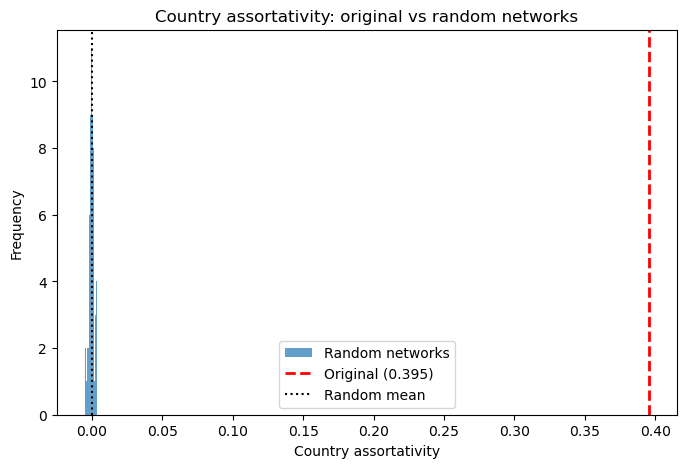

In [100]:
plt.figure(figsize=(8,5))

plt.hist(country_assort_random, bins=20, alpha=0.7, label="Random networks")

plt.axvline(r_country, color='red', linestyle='--', linewidth=2,
            label=f'Original ({r_country:.3f})')

plt.axvline(mean_rand, color='black', linestyle=':', label='Random mean')

plt.legend()
plt.xlabel("Country assortativity")
plt.ylabel("Frequency")
plt.title("Country assortativity: original vs random networks")

plt.show()

The distribution of country assortativity values for the 100 random networks is centered very close to 0, which means that after random rewiring with preserved degree sequence, there is almost no systematic tendency for nodes to connect to others from the same country.

In contrast, the original network has a country assortativity of about 0.396, which lies far to the right of the random-network distribution. This shows that scientists in the original network connect with others from the same country much more often than would be expected by chance alone.

Since the random networks preserve node degrees, this result suggests that the strong country assortativity is not simply caused by the degree distribution, but reflects a real structural pattern in the network. The very large z-score further supports that this difference is highly significant.

> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.

Below we made a function to calculate the degree assortativity discussed in the lecture:

In [101]:
def degree_assortativity_manual(G):
    """
    Manual degree assortativity for an undirected graph.
    Computes Pearson correlation between degrees at the ends of edges.
    """
    x = []
    y = []

    for u, v in G.edges():
        ku = G.degree(u)
        kv = G.degree(v)

        # count both directions for symmetry
        x.extend([ku, kv])
        y.extend([kv, ku])

    mean_x = sum(x) / len(x)
    mean_y = sum(y) / len(y)

    num = sum((a - mean_x) * (b - mean_y) for a, b in zip(x, y))
    den_x = sum((a - mean_x) ** 2 for a in x)
    den_y = sum((b - mean_y) ** 2 for b in y)

    if den_x == 0 or den_y == 0:
        return float("nan")

    return num / math.sqrt(den_x * den_y)

Using the above function we then calculated the requested degree assortativity:

In [102]:
r_degree_original = degree_assortativity_manual(G)
print("Original degree assortativity:", r_degree_original)

Original degree assortativity: -0.09184815409882044


> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 

Similarly to before with country assortativity, we generated 100 random networks and calculated the degree assortativity for each. The output is a sanity check to make sure all swaps were successful and to keep track of how many networks had been created:

In [103]:
degree_assort_random = []

for i in range(100):
    if i % 10 == 0:
        print(f"{i}/100 done")

    G_rand = double_edge_swap_configuration_model_fast(G, seed=i)
    r_rand = degree_assortativity_manual(G_rand)
    degree_assort_random.append(r_rand)

0/100 done
Successful swaps: 515650/515650
Attempts: 518835
Successful swaps: 515650/515650
Attempts: 518889
Successful swaps: 515650/515650
Attempts: 518840
Successful swaps: 515650/515650
Attempts: 518894
Successful swaps: 515650/515650
Attempts: 518853
Successful swaps: 515650/515650
Attempts: 518815
Successful swaps: 515650/515650
Attempts: 518880
Successful swaps: 515650/515650
Attempts: 518934
Successful swaps: 515650/515650
Attempts: 518997
Successful swaps: 515650/515650
Attempts: 518888
10/100 done
Successful swaps: 515650/515650
Attempts: 518885
Successful swaps: 515650/515650
Attempts: 518941
Successful swaps: 515650/515650
Attempts: 518854
Successful swaps: 515650/515650
Attempts: 518828
Successful swaps: 515650/515650
Attempts: 518838
Successful swaps: 515650/515650
Attempts: 518901
Successful swaps: 515650/515650
Attempts: 518984
Successful swaps: 515650/515650
Attempts: 518917
Successful swaps: 515650/515650
Attempts: 518804
Successful swaps: 515650/515650
Attempts: 5188

We also calculated some statistics for this distribution:

In [104]:
mean_deg_rand = np.mean(degree_assort_random)
std_deg_rand = np.std(degree_assort_random)

print("Random mean:", mean_deg_rand)
print("Random std:", std_deg_rand)

z_deg = (r_degree_original - mean_deg_rand) / std_deg_rand
print("Z-score:", z_deg)

Random mean: -0.007406735326813354
Random std: 0.003879857607432264
Z-score: -21.76405098224505


We then plotted the distribution:

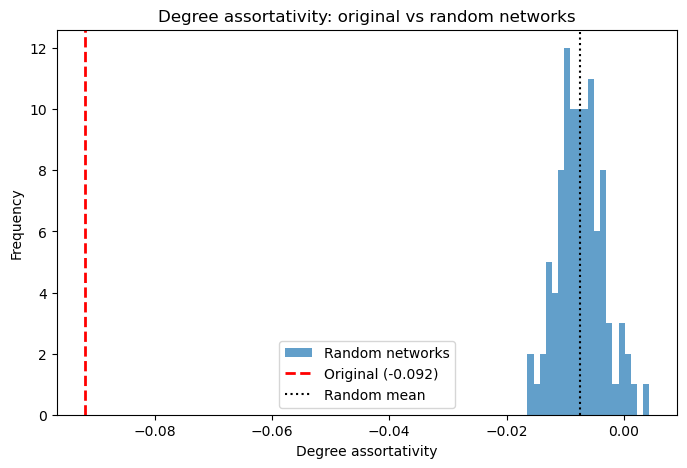

In [105]:
plt.figure(figsize=(8,5))

plt.hist(degree_assort_random, bins=20, alpha=0.7, label="Random networks")

plt.axvline(
    r_degree_original,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Original ({r_degree_original:.3f})'
)

plt.axvline(
    mean_deg_rand,
    color='black',
    linestyle=':',
    label='Random mean'
)

plt.legend()
plt.xlabel("Degree assortativity")
plt.ylabel("Frequency")
plt.title("Degree assortativity: original vs random networks")
plt.show()

The original network has a degree assortativity of about -0.092, while the 100 random networks are centered much closer to 0, with a mean around 0. This means that the real network is substantially more disassortative than would be expected from degree-preserving random rewiring alone.

A negative degree assortativity indicates that high-degree nodes tend to connect to low-degree nodes, rather than to other high-degree nodes. In the context of this network, that suggests that highly connected scientists often collaborate with less connected scientists, instead of forming a tightly interconnected group.

Because the random networks preserve the degree sequence, this difference cannot be explained only by the degree distribution itself. The large negative z-score shows that the observed degree assortativity is far outside the range expected under the random null model, so the effect appears to be a real structural property of the network.

> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?

The result was somewhat plausible, but not necessarily what one would expect if highly connected scientists mainly collaborated with one another. The degree assortativity of the original network was negative (about -0.092), which means the network is disassortative and that high-degree scientists tend to connect more often to lower-degree scientists than to other high-degree scientists.

This can make sense in a collaboration network. Well-known or very active researchers may collaborate with many different people, including less connected researchers, students, or newcomers. That creates many edges between high-degree and low-degree nodes, which pushes the assortativity in the negative direction.

So while one might initially expect top researchers to cluster together, the observed negative assortativity is still reasonable for this kind of real-world collaboration network.


> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?

The edge-flipping step is included to avoid introducing systematic bias when rewiring edges. Since the network is undirected, the edges (u,v) and (v,u) represent the same connection, but when implementing the double-edge swap algorithm, the ordering of endpoints can affect which new pairings are created.

By flipping one of the edges 50% of the time before swapping, we randomize the orientation used in the rewiring step. This makes the rewiring process more symmetric and helps ensure that all valid rewirings are sampled more fairly. In other words, edge flipping improves the randomness of the generated networks and reduces the chance that the algorithm favors one rewiring pattern over another.


> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random 
networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.   

The degree assortativity values of the random networks formed a fairly narrow distribution centered close to 0, though slightly on the negative side. In our results, the random mean was about -0.007, with a small standard deviation of about 0.0039. This means that most of the randomized networks had only weak degree assortativity.

This pattern is broadly what we would expect. The configuration model preserves the degree of every node but randomizes which nodes are connected. Because of that, any strong mixing pattern from the original network should mostly disappear, and the assortativity values should cluster near 0. The fact that the distribution is narrow also makes sense, since all random networks are generated under the same degree constraints.

The distribution was not centered at exactly 0, but that is not surprising. Small deviations can occur because the random networks are finite in size, because the rewiring process is constrained to avoid invalid swaps such as self-loops or duplicate edges, and because the configuration-model procedure does not sample every possible graph completely uniformly in practice. The edge-flipping step helps make the rewiring more symmetric, which supports a more balanced randomization process, but we can still expect a small spread around 0 rather than one exact value.

Overall, the observed distribution aligns well with theoretical expectations: the randomized networks largely remove the original structural mixing pattern while preserving the degree sequence, and this is exactly why the original network stands out so clearly with a much more negative assortativity value.

# Part 2: TF-IDF

> __Exercise 1: TF-IDF and the Computational Social Science communities__  
> The goal for this exercise is to find the words characterizing each of the communities of Computational Social Scientists. What you need for this exercise:
>
> - The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.
> - the tokenized *abstract* dataframe (Week 7, Exercise 2)
>
> 1. First, check out the [wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF.
>    - What does TF stand for?
>    - What does IDF stand for?
>

TF stands for "term frequency". It tells how often a word/term *t* appears in a document *d*. It is calculated using this formula:

$\mathrm{tf}(t, d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$

The numerator is the number of times a term *t* appears in document *d*, and the denominator is the total number of terms in document *d*.

IDF stands for "inverse document frequency". It tells how rare a given term *t* is across a set of documents *D*. It is calculated using this formula:

$\mathrm{idf}(t, D) = \log \frac{N}{n_t}$

*N* is the total amount of documents in the set *D*, and $n_t$ is the number of documents where the term *t* appears. 

The purpose of TF-IDF is to find words that are important for describing a specific community. TF measures how often a word appears in that community, while IDF reduces the weight of words that are common across many communities. Therefore, TF-IDF highlights words that are both frequent in one community and distinctive compared to the others.

> 2. Now, we want to find out which words are important for each *community*, so we're going to create several *large documents*, one for each community. Each document includes all the tokens of abstracts written by members of a given community.
>
>    - Consider a community `c`
>    - Find all the abstracts of papers written by a member of community `c`.
>    - Create a long array that stores all the abstract tokens
>    - Repeat for all the communities.  
>      **Note:** Here, to ensure your code is efficient, you shall exploit `pandas` builtin functions, such as `groupby.apply` or `explode`.
>

Import all necessary files:

In [106]:
import pandas as pd
import ast
from collections import defaultdict, Counter
import math

Load all required files:

In [107]:
author_comm = pd.read_csv("author_communities.csv")
df = pd.read_csv("abstracts_with_collocations.csv")
fp = pd.read_csv("final_papers.csv")
fa = pd.read_csv("final_authors.csv")

First we convert all string columns to lists:

In [108]:
fp["author_ids"] = fp["author_ids"].apply(ast.literal_eval)
df["tokens_collocations"] = df["tokens_collocations"].apply(ast.literal_eval)

We then use the ```explode``` function to split each index in the author ids list into separate rows. We also rename the author_ids column to author and remove NaNs from author to avoid any issues later on:

In [109]:
fp_exploded = fp.explode("author_ids").rename(columns={"author_ids": "author"})
fp_exploded = fp_exploded.dropna(subset=["author"])

We then merge the ```fp_exploded``` file with the ```author_comm``` file and remove all NaNs from the community column. This will help avoid issues later on:

In [110]:
paper_author_info = fp_exploded.merge(author_comm, on="author", how="left")
paper_author_info = paper_author_info.dropna(subset=["community"])

We then merge this file with the ```df``` file. We also displayed the head of the file below to be sure that everything looked like it was supposed to:

In [111]:
df_merged = paper_author_info.merge(df, on="id", how="inner")
df_merged.head()

,id,publication_year,cited_by_count,author,community,degree,title,abstract_inverted_index,text,tokens,filtered_tokens,bigrams,tokens_collocations
0,https://openalex.org/W2115022330,2007.0,3050,https://openalex.org/A5083710366,0.0,39.0,Measurement and analysis of online social netw...,"{'Online': [0], 'social': [1, 24, 53, 76], 'ne...","Online social networking sites like Orkut, You...","['onlin', 'social', 'network', 'site', 'like',...","['onlin', 'social', 'network', 'site', 'like',...","[('onlin', 'social'), ('social', 'network'), (...","[onlin_social, network_site, like, orkut, yout..."
1,https://openalex.org/W2115022330,2007.0,3050,https://openalex.org/A5067688305,0.0,73.0,Measurement and analysis of online social netw...,"{'Online': [0], 'social': [1, 24, 53, 76], 'ne...","Online social networking sites like Orkut, You...","['onlin', 'social', 'network', 'site', 'like',...","['onlin', 'social', 'network', 'site', 'like',...","[('onlin', 'social'), ('social', 'network'), (...","[onlin_social, network_site, like, orkut, yout..."
2,https://openalex.org/W2115022330,2007.0,3050,https://openalex.org/A5019096316,0.0,2.0,Measurement and analysis of online social netw...,"{'Online': [0], 'social': [1, 24, 53, 76], 'ne...","Online social networking sites like Orkut, You...","['onlin', 'social', 'network', 'site', 'like',...","['onlin', 'social', 'network', 'site', 'like',...","[('onlin', 'social'), ('social', 'network'), (...","[onlin_social, network_site, like, orkut, yout..."
3,https://openalex.org/W2522448907,2016.0,2339,https://openalex.org/A5016636016,1.0,3.0,MedRec: Using Blockchain for Medical Data Acce...,"{'Years': [0], 'of': [1, 36, 161, 168, 190], '...",Years of heavy regulation and bureaucratic ine...,"['year', 'heavi', 'regul', 'bureaucrat', 'inef...","['year', 'heavi', 'regul', 'bureaucrat', 'inef...","[('year', 'heavi'), ('heavi', 'regul'), ('regu...","[year, heavi, regul, bureaucrat, ineffici, slo..."
4,https://openalex.org/W2522448907,2016.0,2339,https://openalex.org/A5075991638,1.0,2.0,MedRec: Using Blockchain for Medical Data Acce...,"{'Years': [0], 'of': [1, 36, 161, 168, 190], '...",Years of heavy regulation and bureaucratic ine...,"['year', 'heavi', 'regul', 'bureaucrat', 'inef...","['year', 'heavi', 'regul', 'bureaucrat', 'inef...","[('year', 'heavi'), ('heavi', 'regul'), ('regu...","[year, heavi, regul, bureaucrat, ineffici, slo..."


We now create a smaller version of the dataframe so we only have the information we need, and we keep one copy per paper-community pair to avoid duplicates. Here we also displayed the head of the file to be sure that everything looked right:

In [112]:
df_small = df_merged[["id", "community", "tokens_collocations"]].copy()
df_small = df_small.drop_duplicates(subset=["id", "community"])
df_small.head()

,id,community,tokens_collocations
0,https://openalex.org/W2115022330,0.0,"[onlin_social, network_site, like, orkut, yout..."
3,https://openalex.org/W2522448907,1.0,"[year, heavi, regul, bureaucrat, ineffici, slo..."
6,https://openalex.org/W1586856071,2.0,"[paper_describ, studi_assess, influenc, variet..."
8,https://openalex.org/W2171057921,2.0,"[group, experi_carri, assess_whether, two_diff..."
9,https://openalex.org/W2113920515,2.0,"[paper_describ, experi_compar, behavior, small..."


Here we find the top communities by the number of authors:

In [113]:
community_author_counts = (
    paper_author_info[["author", "community"]]
    .drop_duplicates()
    .groupby("community")["author"]
    .nunique()
    .sort_values(ascending=False)
)

top5_communities = community_author_counts.head(5).index.tolist()
top9_communities = community_author_counts.head(9).index.tolist()

print("Top 5 communities by number of authors:")
print(community_author_counts.head(5))

print("\nTop 9 communities by number of authors:")
print(community_author_counts.head(9))

Top 5 communities by number of authors:
community
6.0     658
10.0    620
1.0     606
32.0    497
43.0    488
Name: author, dtype: int64

Top 9 communities by number of authors:
community
6.0     658
10.0    620
1.0     606
32.0    497
43.0    488
13.0    439
49.0    429
30.0    427
63.0    417
Name: author, dtype: int64


Now we build one document per community:

In [114]:
community_docs = defaultdict(list)

for row in df_small.itertuples(index=False):
    community_docs[row.community].extend(row.tokens_collocations)

print(f"Number of communities with documents: {len(community_docs)}")
print("Example community:", list(community_docs.keys())[0])
print("First 20 tokens from that community document:")
print(community_docs[list(community_docs.keys())[0]][:20])

Number of communities with documents: 230
Example community: 0.0
First 20 tokens from that community document:
['onlin_social', 'network_site', 'like', 'orkut', 'youtub', 'flickr', 'among', 'popular', 'site', 'internet_user', 'site', 'form_social', 'network_provid', 'power', 'mean', 'share', 'organ_find', 'content', 'contact', 'popular']


> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the **top 5 communities** (by number of authors).

The questions asked in this exercise are below the code

First we calculate the TF for each community document:

In [115]:
tf = {}

for comm, tokens in community_docs.items():
    counts = Counter(tokens)
    total = sum(counts.values())
    tf[comm] = {word: count / total for word, count in counts.items()}

# Testing one example for sanity check
example_comm = list(tf.keys())[0]
print("Example community:", example_comm)
print("Top 10 TF words:")
print(sorted(tf[example_comm].items(), key=lambda x: x[1], reverse=True)[:10])

Example community: 0.0
Top 10 TF words:
[('user', 0.003896421582331563), ('use', 0.003717325971484484), ('network', 0.0029266843723790886), ('data', 0.0028393206597707578), ('system', 0.002437447581772435), ('base', 0.002223406485882024), ('model', 0.002144779144534526), ('differ', 0.0019263698630136985), ('commun', 0.0019176334917528656), ('algorithm', 0.001882688006709533)]


Then we find the top 5 TF words for the top 5 communities:

In [116]:
rows_top5_tf = []

for comm in top5_communities:
    top_tf_words = sorted(tf[comm].items(), key=lambda x: x[1], reverse=True)[:5]
    
    rows_top5_tf.append({
        "community": comm,
        "n_authors": community_author_counts.loc[comm],
        "TF_top5": ", ".join([w for w, _ in top_tf_words])
    })

tf_top5_table = pd.DataFrame(rows_top5_tf).sort_values("n_authors", ascending=False)

print("Top 5 TF words in the top 5 communities:")
tf_top5_table

Top 5 TF words in the top 5 communities:


,community,n_authors,TF_top5
0,6.0,658,"group, effect, studi, use, peopl"
1,10.0,620,"use, user, design, commun, student"
2,1.0,606,"use, model, gener, algorithm, set"
3,32.0,497,"model, imag, learn, gener, method"
4,43.0,488,"agent, use, model, gener, learn"


>    - Describe similarities and differences between the communities.

There are clear similarities across the communities, since several words appear repeatedly in the top terms. In particular, words such as *use*, *model*, *gener*, and *learn* occur in multiple communities. This suggests that many of the communities share a common computational or methodological foundation, which makes sense in a Computational Social Science network.

At the same time, there are also noticeable differences. Community 6.0 seems to be more oriented toward social and behavioral topics, with words such as *group*, *effect*, *studi*, and *peopl*. Community 10.0 appears more focused on interaction, design, and communication, with terms like *user*, *design*, *commun*, and *student*. Community 1.0 looks more algorithmic or technical, with words such as *model*, *gener*, *algorithm*, and *set*. Community 32.0 seems related to machine learning or computer vision, with *model*, *imag*, *learn*, *gener*, and *method*. Community 43.0 also appears computational, but with a stronger emphasis on *agent*-based or learning-oriented work.

Overall, the results suggest that Computational Social Science contains both shared computational methods and distinct thematic sub-communities.

>    - Why aren't the TFs not necessarily a good description of the communities?

TFs are not necessarily a good description of the communities because they mainly highlight the most frequent words, and those words are often quite general. In our results, terms such as *use*, *model*, *gener*, and *learn* appear across several communities. These words tell us something about the overall style of research in the field, but they do not clearly distinguish one community from another.

This means that TF alone tends to emphasize broad and common vocabulary rather than the words that are uniquely characteristic of a specific community. As a result, TF is useful for showing what is frequent, but it is less effective when the goal is to describe what makes each community distinct.

>    - Next, we calculate IDF for every word.
>    - What base logarithm did you use? Is that important?

We used the natural logarithm, since Python’s `math.log()` computes the logarithm with base \(e\) by default. 

The exact choice of logarithm base is not very important here. Changing the base only rescales all IDF values by the same constant factor, so it does not change the ranking of the words. Therefore, the interpretation of which words are most important remains the same.

> 4. We're ready to calculate TF-IDF. Do that for the **top 9 communities** (by number of authors). Then for each community:
>
>    - List the 10 top TF words
>    - List the 10 top TF-IDF words
>    - List the top 3 authors (by degree)

The question asked in this exercise is again located below the code.

First we calculated the IDF:

In [117]:
N = len(community_docs)

doc_freq = Counter()

for tokens in community_docs.values():
    unique_words = set(tokens)
    for word in unique_words:
        doc_freq[word] += 1

idf = {word: math.log(N / dfreq) for word, dfreq in doc_freq.items()}

# Sanity check of a few values
example_words = list(idf.items())[:10]
print("Example IDF values:")
for w, v in example_words:
    print(w, ":", v)

Example IDF values:
cross_valid : 1.4307461236907244
simul_model : 1.4677873953710736
sa : 1.486835590341768
three_day : 2.493640329756755
greeneri : 3.040184036124825
decompos : 1.17539943188188
metaphorgold : 5.438079308923196
room : 1.2185716037470886
part_base : 2.3470368555648795
wearabl_devic : 1.6314168191528755


Then we calculated the TF-IDF:

In [118]:
tfidf = {}

for comm in tf:
    tfidf[comm] = {}
    for word in tf[comm]:
        tfidf[comm][word] = tf[comm][word] * idf[word]

# Sanity check
example_comm = list(tfidf.keys())[0]
print("Example community:", example_comm)
print("Top 10 TF-IDF words:")
print(sorted(tfidf[example_comm].items(), key=lambda x: x[1], reverse=True)[:10])

Example community: 0.0
Top 10 TF-IDF words:
[('user', 0.002909580447175942), ('persona', 0.0018010821882338472), ('soundscap', 0.0017484106052603218), ('network', 0.001647377911106415), ('fair', 0.0015407533949506867), ('tweet', 0.00134584792301651), ('algorithm', 0.0012886794528369357), ('servic', 0.001171137089394032), ('app', 0.0011338372541928664), ('social_media', 0.0011148017791501128)]


We then extracted the top 10 TF and TF-IDF words from the top 9 communities:

In [119]:
rows_top9 = []

for comm in top9_communities:
    top_tf_words = sorted(tf[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    top_tfidf_words = sorted(tfidf[comm].items(), key=lambda x: x[1], reverse=True)[:10]

    rows_top9.append({
        "community": comm,
        "n_authors": community_author_counts.loc[comm],
        "TF_top10": ", ".join([w for w, _ in top_tf_words]),
        "TFIDF_top10": ", ".join([w for w, _ in top_tfidf_words]),
    })

tfidf_table = pd.DataFrame(rows_top9).sort_values("n_authors", ascending=False)

print("Top 10 TF and TF-IDF words for the top 9 communities:")
tfidf_table

Top 10 TF and TF-IDF words for the top 9 communities:


,community,n_authors,TF_top10,TFIDF_top10
0,6.0,658,"group, effect, studi, use, peopl, particip, mo...","emot, ingroup, group, attitud, ident, belief, ..."
1,10.0,620,"use, user, design, commun, student, interact, ...","user, student, learn, design, task, social_med..."
2,1.0,606,"use, model, gener, algorithm, set, data, show,...","algorithm, user, ai, auction, set, agent, task..."
3,32.0,497,"model, imag, learn, gener, method, featur, pro...","video, imag, extens_experi, learn, represent, ..."
4,43.0,488,"agent, use, model, gener, learn, show, system,...","agent, music, auction, argument, learn, game, ..."
5,13.0,439,"use, citi, model, system, data, network, base,...","citi, urban, network, user, queri, evacu, syst..."
6,49.0,429,"network, use, model, data, vaccin, commun, dyn...","vaccin, epidem, infect, network, varicella, tr..."
7,30.0,427,"effect, model, use, process, test, differ, dec...","memori, item, choic, decis, judgment, misinfor..."
8,63.0,417,"person, use, measur, effect, studi, model, rel...","adolesc, trait, person, person_trait, parent, ..."


Then we found the top 3 authors by degree in each of the top 9 communities:

In [120]:
df_auth = df_merged[["author", "community", "degree"]].drop_duplicates().copy()

top_authors_top9 = (
    df_auth[df_auth["community"].isin(top9_communities)]
    .sort_values(["community", "degree"], ascending=[True, False])
    .groupby("community")
    .head(3)
    .copy()
)

author_name_map = dict(zip(fa["id"], fa["display_name"]))
top_authors_top9["author_name"] = top_authors_top9["author"].map(author_name_map)

print("Top 3 authors by degree in the top 9 communities:")
top_authors_top9[["community", "author_name", "author", "degree"]].sort_values(
    ["community", "degree"], ascending=[True, False]
)

Top 3 authors by degree in the top 9 communities:


,community,author_name,author,degree
602,1.0,Dan Jurafsky,https://openalex.org/A5087088138,154.0
6510,1.0,Marzyeh Ghassemi,https://openalex.org/A5070063054,121.0
1482,1.0,Jon Kleinberg,https://openalex.org/A5055710645,111.0
7127,6.0,Matthew J. Hornsey,https://openalex.org/A5021448872,91.0
7642,6.0,Nick Haslam,https://openalex.org/A5090589044,91.0
1056,6.0,Anne Maass,https://openalex.org/A5037013778,73.0
5470,10.0,Michael S. Bernstein,https://openalex.org/A5076189854,154.0
68,10.0,Diyi Yang,https://openalex.org/A5089413311,91.0
12281,10.0,Éric Gilbert,https://openalex.org/A5024795472,73.0
782,13.0,Marta C. González,https://openalex.org/A5111672074,98.0


>    - Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

Yes, the TF-IDF words are generally more descriptive of the communities than the TF words alone. In the TF lists, many of the top words are broad and repeated across several communities, such as *use*, *model*, *data*, *network*, *effect*, and *learn*. These words are frequent, but they do not say very much about what makes one community distinct from another.

The TF-IDF lists are much more specific. For example, community 6.0 is characterized by words such as *emot*, *ingroup*, *attitud*, *ident*, and *belief*, which suggest a focus on social psychology and group processes. Community 49.0 has words such as *vaccin*, *epidem*, *infect*, and *varicella*, which point clearly to epidemic modeling and disease spread. Community 63.0 is associated with *adolesc*, *trait*, *person*, and *parent*, which indicates a focus on personality and developmental or family-related research. In the same way, community 13.0 contains words like *citi*, *urban*, *queri*, and *evacu*, suggesting urban systems and mobility, while community 32.0 contains *video*, *imag*, and *represent*, which makes it look much more related to machine learning or computer vision.

IDF makes the words more informative because it down-weights words that appear in many communities and gives relatively higher weight to words that are concentrated in only a few communities. This removes some of the generic field-wide vocabulary and highlights the terms that are more unique to each community. As a result, TF-IDF gives a clearer picture of the special focus of each sub-community.

> __Exercise 2: The Wordcloud__  
> It's time to visualize our results!
>
> - Install the `wordcloud` module.
> - Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> - Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration).
> - Comment on your results. What can you conclude on the different sub-communities in Computational Social Science?
> - Look up online the top author in each community. In light of your search, do your results make sense?

Answers to the questions in the exercise are located below the code.

Import necessary packages:

In [121]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Here we created word clouds for each of the top 9 communities. The names of the top 3 authors are displayed next to each word cloud: 

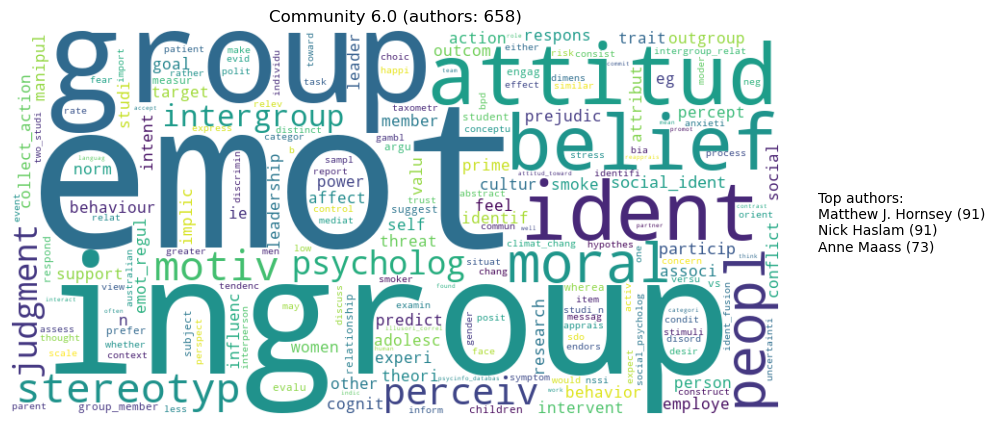

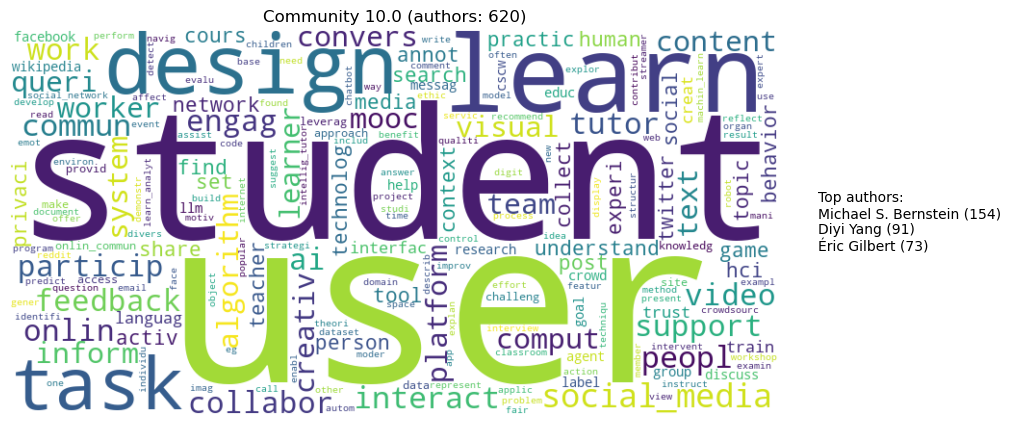

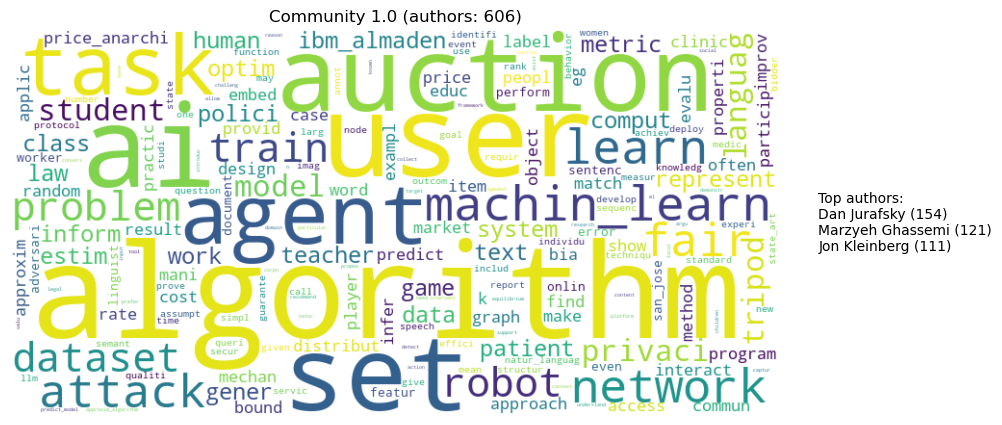

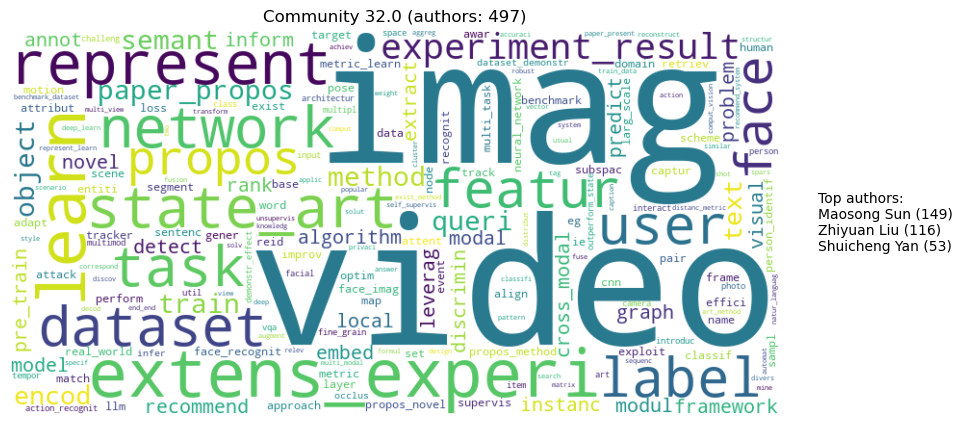

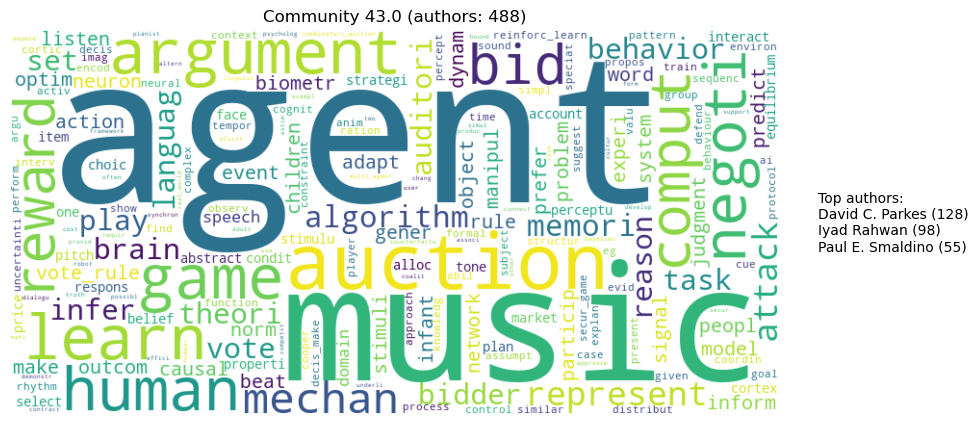

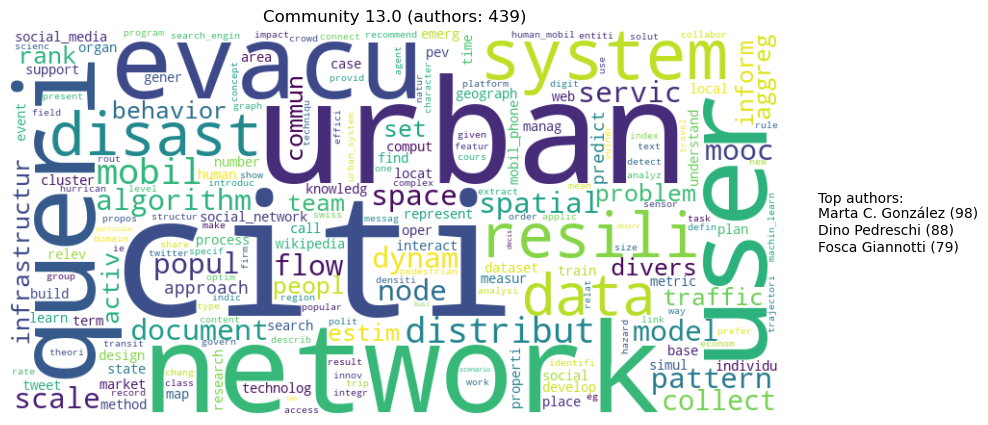

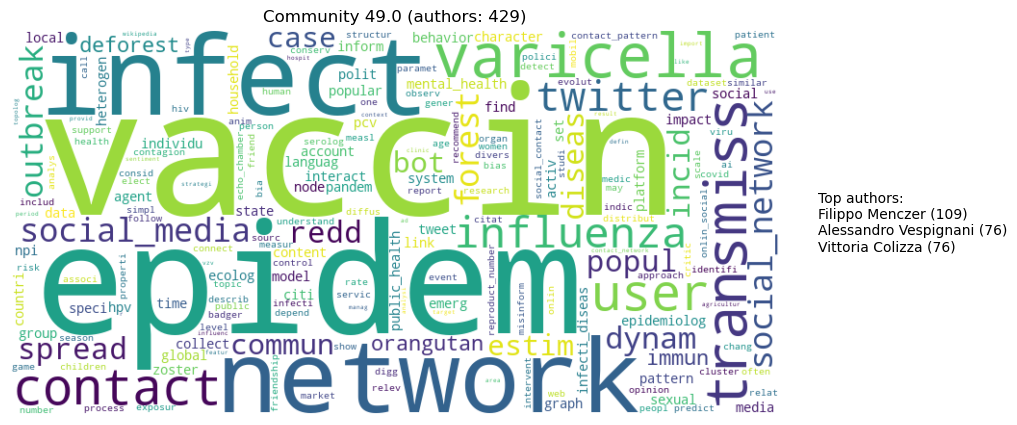

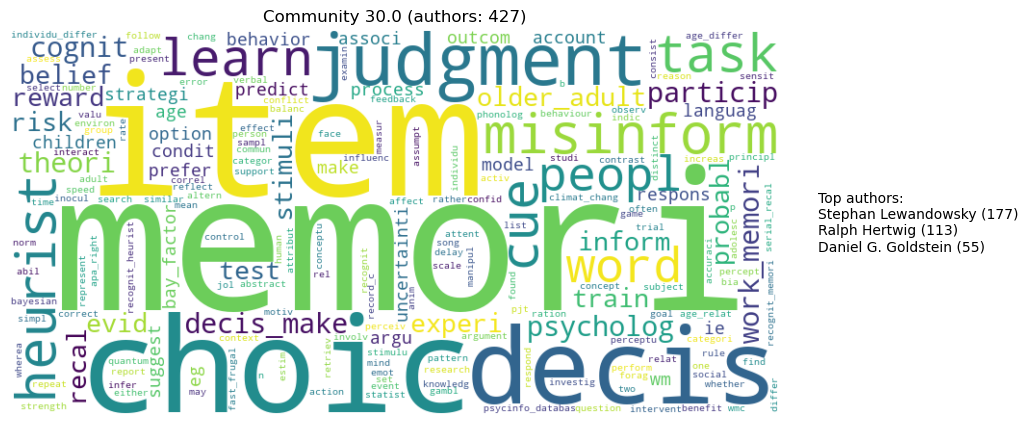

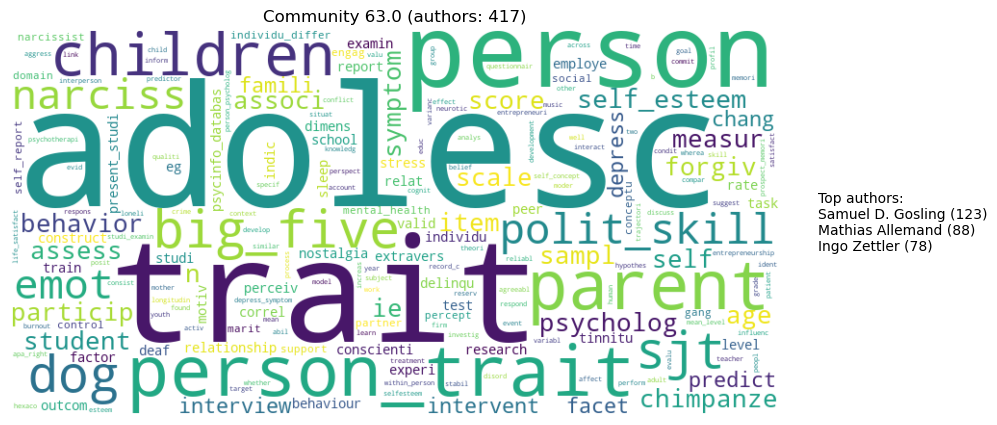

In [122]:
for comm in top9_communities:
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(tfidf[comm])

    authors = top_authors_top9[top_authors_top9["community"] == comm]

    author_text = "\n".join([
        f"{row['author_name'] if pd.notna(row['author_name']) else row['author'].split('/')[-1]} ({int(row['degree'])})"
        for _, row in authors.iterrows()
    ])

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Community {comm} (authors: {community_author_counts.loc[comm]})")

    plt.text(
        1.05, 0.5,
        f"Top authors:\n{author_text}",
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="center"
    )

    plt.show()

> - Comment on your results. What can you conclude on the different sub-communities in Computational Social Science?

The word clouds suggest that Computational Social Science is not one homogeneous field, but instead consists of several distinct sub-communities. Some communities appear more related to social psychology and identity, others to human-computer interaction and online behavior, others to algorithms and AI, others to urban systems and mobility, others to epidemics and diffusion, and others to personality-related research. Overall, the word clouds indicate that the field combines shared computational methods with quite different substantive research topics.

> - Look up online the top author in each community. In light of your search, do your results make sense?

Yes, the results seem to make sense when compared with the top authors in each community. For example, community 1.0 includes Dan Jurafsky and Jon Kleinberg, which fits a community with words such as *algorithm*, *ai*, and *agent*. Community 10.0 includes Michael S. Bernstein, which aligns well with words like *user*, *design*, and *social_media*. Community 13.0 includes Marta C. González, whose work is strongly connected to urban systems and mobility, matching words such as *citi*, *urban*, and *evacu*. Community 30.0 includes Stephan Lewandowsky, which fits well with words such as *memori*, *choic*, *judgment*, and *misinfor*. Community 63.0 includes Samuel D. Gosling, which is consistent with terms like *trait*, *person*, *adolesc*, and *parent*. Overall, the top authors support the interpretation that the detected communities correspond to meaningful subfields within Computational Social Science.


> __Exercise 3: Computational Social Science__
>
> - In light of your data-driven analysis, has your understanding of the field changed? How?

Yes, our understanding of the field has become more nuanced through this analysis. Before doing the exercise, we thought of Computational Social Science mainly as a single interdisciplinary field that applies computational methods to social questions. After the analysis, it seems more accurate to view it as a broader umbrella containing several distinct sub-communities with different thematic and methodological emphases.

The network structure and the text analysis both suggest that the field is organized into recognizable clusters. Some communities appear more focused on social psychology, personality, and attitudes, while others are more oriented toward HCI (Human-Computer Interaction), AI, urban systems, epidemics, or misinformation and decision-making. At the same time, the repeated appearance of common words such as *model*, *data*, *network*, and *use* shows that these communities still share a common computational foundation.